In [ ]:
import pandas as pd

from google.colab import files
uploaded=files.upload()

Saving Loan Prediction.csv to Loan Prediction.csv


In [ ]:
df = pd.read_csv("Loan Prediction.csv")
df.head()

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


In [ ]:
df = df.drop("Id", axis=1)

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("Risk_Flag", axis=1)
y = df["Risk_Flag"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['Recall', 'Precision']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,473 (52.63 KB)

 Trainable params: 13,473 (52.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
5040/5040 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - Precision: 0.1852 - Recall: 0.6264 - loss: 0.6528 - val_Precision: 0.2841 - val_Recall: 0.7799 - val_loss: 0.5595
Epoch 2/50
5040/5040 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - Precision: 0.3310 - Recall: 0.7812 - loss: 0.4920 - val_Precision: 0.3462 - val_Recall: 0.8292 - val_loss: 0.5029
Epoch 3/50
5040/5040 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - Precision: 0.3950 - Recall: 0.8378 - loss: 0.4271 - val_Precision: 0.3824 - val_Recall: 0.8174 - val_loss: 0.4584
Epoch 4/50
5040/5040 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - Precision: 0.4179 - Recall: 0.8488 - loss: 0.3986 - val_Precision: 0.4307 - val_Recall: 0.8091 - val_loss: 0.3951
Epoch 5/50
5040/5040 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - Precision: 0.4351 - Recall: 0.8658 - loss: 0.3808 - val_Precision: 0.4387 - val_Recall: 0.8211 - val_loss: 0.3965
Epoch 6/50
5040/5040 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - Precision: 0.4467 - Recall: 0.8719 - loss: 0.3675 - val_Precision: 0.4443 - val_Recall: 

In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print("Confusion matrix: ", confusion_matrix(y_test, y_pred))

Accuracy: 0.8642063492063492
Precision: 0.47089612850825735
Recall: 0.8417486691401839
F1 score: 0.6039351851851852
Confusion matrix:  [[38338  5863]
 [  981  5218]]


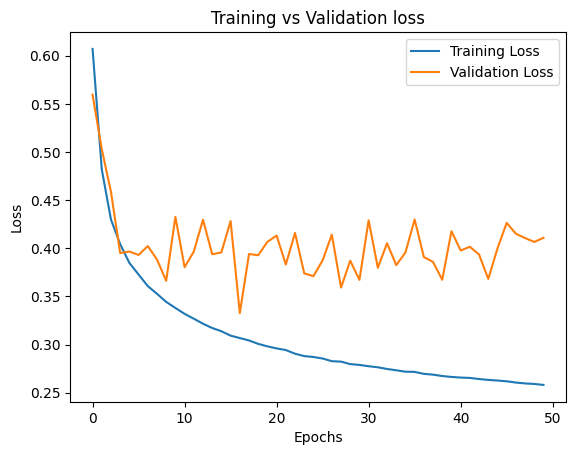

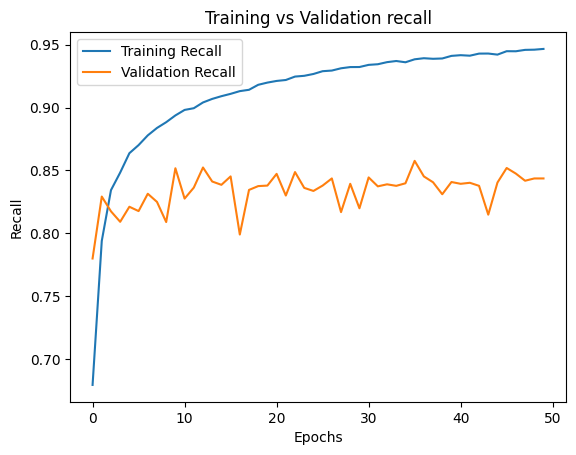

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['Recall'], label='Training Recall')
plt.plot(history.history['val_Recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Training vs Validation recall')
plt.legend()
plt.show()

In [ ]:
#Model interpretation
#The model is performing well with no severe overfitting